In [22]:
%pip install pandas numpy scikit-learn tensorflow joblib

Note: you may need to restart the kernel to use updated packages.


In [23]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras

In [24]:
df = pd.read_csv('./placementdata.csv')
df.head()

,StudentID,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,1,7.5,1,1,1,65,4.4,No,No,61,79,NotPlaced
1,2,8.9,0,3,2,90,4.0,Yes,Yes,78,82,Placed
2,3,7.3,1,2,2,82,4.8,Yes,No,79,80,NotPlaced
3,4,7.5,1,1,2,85,4.4,Yes,Yes,81,80,Placed
4,5,8.3,1,2,2,86,4.5,Yes,Yes,74,88,Placed


In [25]:
# Encode categorical columns
le = LabelEncoder()
for col in ['ExtracurricularActivities', 'PlacementTraining', 'PlacementStatus']:
    df[col] = le.fit_transform(df[col])

df = df.drop(columns=['StudentID'])
df.head()

,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus
0,7.5,1,1,1,65,4.4,0,0,61,79,0
1,8.9,0,3,2,90,4.0,1,1,78,82,1
2,7.3,1,2,2,82,4.8,1,0,79,80,0
3,7.5,1,1,2,85,4.4,1,1,81,80,1
4,8.3,1,2,2,86,4.5,1,1,74,88,1


In [26]:
# Feature Engineering
df['CGPA_x_Aptitude']            = df['CGPA'] * df['AptitudeTestScore']
df['Total_Marks']                = df['SSC_Marks'] + df['HSC_Marks']
df['Training_x_Extracurricular'] = df['PlacementTraining'] * df['ExtracurricularActivities']
df['CGPA_x_Projects']            = df['CGPA'] * df['Projects']
df['Aptitude_x_SoftSkills']      = df['AptitudeTestScore'] * df['SoftSkillsRating']

print('Features after engineering:', df.shape[1] - 1)
df.head()

Features after engineering: 15


,CGPA,Internships,Projects,Workshops/Certifications,AptitudeTestScore,SoftSkillsRating,ExtracurricularActivities,PlacementTraining,SSC_Marks,HSC_Marks,PlacementStatus,CGPA_x_Aptitude,Total_Marks,Training_x_Extracurricular,CGPA_x_Projects,Aptitude_x_SoftSkills
0,7.5,1,1,1,65,4.4,0,0,61,79,0,487.5,140,0,7.5,286.0
1,8.9,0,3,2,90,4.0,1,1,78,82,1,801.0,160,1,26.7,360.0
2,7.3,1,2,2,82,4.8,1,0,79,80,0,598.6,159,0,14.6,393.6
3,7.5,1,1,2,85,4.4,1,1,81,80,1,637.5,161,1,7.5,374.0
4,8.3,1,2,2,86,4.5,1,1,74,88,1,713.8,162,1,16.6,387.0


In [27]:
X = df.drop(columns=['PlacementStatus'])
y = df['PlacementStatus']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Train size: (8000, 15), Test size: (2000, 15)


In [28]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),

    keras.layers.Dense(128, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),

    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),

    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.1),

    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                      │ (None, 128)                 │           2,048 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_8                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,865 (50.25 KB)

 Non-trainable params: 448 (1.75 KB)

In [29]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=7, min_lr=1e-6, verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7720 - loss: 0.5090 - val_accuracy: 0.7912 - val_loss: 0.4559 - learning_rate: 0.0010
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.7828 - loss: 0.4661 - val_accuracy: 0.7981 - val_loss: 0.4454 - learning_rate: 0.0010
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7856 - loss: 0.4565 - val_accuracy: 0.8044 - val_loss: 0.4450 - learning_rate: 0.0010
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.7936 - loss: 0.4560 - val_accuracy: 0.8025 - val_loss: 0.4428 - learning_rate: 0.0010
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.7934 - loss: 0.4463 - val_accuracy: 0.8044 - val_loss: 0.4426 - learning_rate: 0.0010
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7950 - loss: 0.4504 - val_accuracy: 0.8037 - val_loss: 0.4408 - learning_rate: 0.0010
Epoch 7/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7969 - 

In [30]:
y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()

print(f'ANN Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=['NotPlaced', 'Placed']))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
ANN Accuracy: 0.7925

Classification Report:
              precision    recall  f1-score   support

   NotPlaced       0.81      0.84      0.83      1172
      Placed       0.76      0.72      0.74       828

    accuracy                           0.79      2000
   macro avg       0.79      0.78      0.78      2000
weighted avg       0.79      0.79      0.79      2000



In [31]:
# Save model and scaler for the Streamlit app
model.save('placement_ann_model.keras')
joblib.dump(scaler, 'placement_scaler.pkl')
print('Model and scaler saved.')

Model and scaler saved.


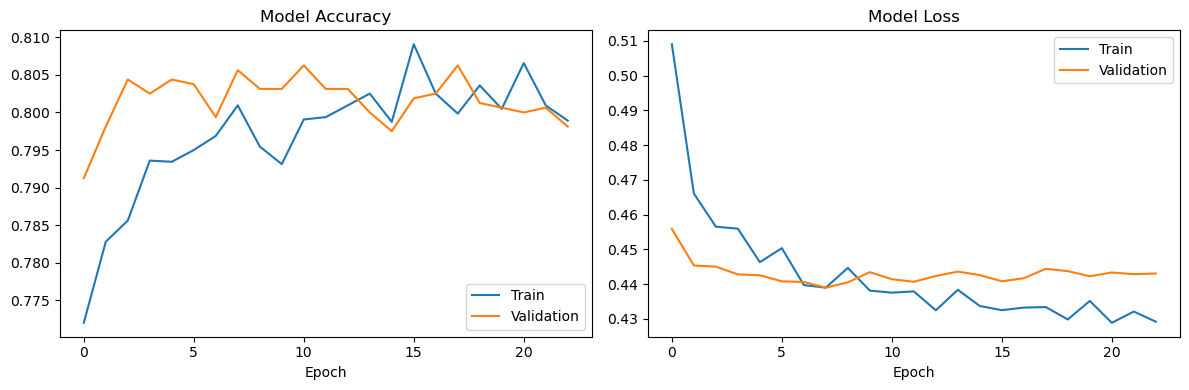

In [32]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Train')
ax1.plot(history.history['val_accuracy'], label='Validation')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(history.history['loss'], label='Train')
ax2.plot(history.history['val_loss'], label='Validation')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()